# **Bank Telemarketing Dataset -- EDA Approach**

In [18]:
import sys
sys.path.append("..")

import src.my_library as my_library
import src.my_file as my_file

In [19]:
## Import commonly used libraries
import pandas as pd
from pathlib import Path

## Display Setting

In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [21]:
pd, np, plt, sns = my_library.make_inital_imports()

In [22]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [23]:
tele_df = my_library.load_data(data_path.joinpath("bank-additional-full.csv"))
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [24]:
tele_df.shape

(41188, 21)

In [25]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [26]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [32]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


### **Brief description of Columns:**

**Bank Client Data Description:**

- **age**: Age of the client (numeric)
- **job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **marital**: Marital status (categorical: 'divorced', 'married', 'single', 'unknown')
- **education**: Level of education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- **default**: Whether the client has credit in default (binary: 'no', 'yes', 'unknown')
- **housing**: Whether the client has a housing loan (binary: 'no', 'yes', 'unknown')
- **loan**: Whether the client has a personal loan (binary: 'no', 'yes', 'unknown')

**Last Contact Data Description:**

- **contact**: Type of communication used to contact the client (categorical: 'cellular', 'telephone')
- **month**: Last contact month of the year (categorical: 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec')
- **day_of_week**: Last contact day of the week (categorical: 'mon', 'tue', 'wed', 'thu', 'fri')
- **duration**: Duration of the last contact in seconds (numeric)
Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model

**Campaign Data Description:**

- **campaign**: Number of contacts performed during this campaign for this client (numeric, includes last contact)
- **pdays**: Number of days since the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
- **previous**: Number of contacts performed before this campaign for this client (numeric) 
- **poutcome**: Outcome of the previous marketing campaign (categorical: 'failure', 'nonexistent', 'success')

**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
- **cons.price.idx**: Consumer price index - monthly indicator (numeric)
- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)
- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


***Dataset Summary:***

**This dataset represents the direct marketing campaign(phone calls) of a Portuguese banking institution, where each record represents a client and the outcome of a marketing campaign to convince the client to subscribe a term deposit. The dataset contains both categorical and numerical features describing each client's demographics, behaviroal, social and economic context, with a binary target variable indicating whether the client subscribed to a term deposit. The data spans from May 2008 to November 2010**

## **Formatting and Consistency Check**

In [36]:
# For numerical columns
def highlight_neg_zero(val):
    if pd.isna(val):
        return "background-color: gray; color: white"
    elif val == 0:
        return "color: k; background-color: yellow"
    elif val < 0:
        return "color: k; background-color: red"
    else:
        return ""


desc_df = tele_df.describe()
style_df = desc_df.style.applymap(highlight_neg_zero)
style_df

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.024060,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.421250,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Investigate:**
- **duration** contains 0 values which is not possible as it is the call duration in seconds.
- **pdays** contains 0.
- **previous** contains 0 value.
- **emp_var_rate** and **cons_conf_idx** contains negative values.


In [37]:
# highlight repeated values in numeric values
def highlight_repeats(ser):
    is_duplicated = ser.duplicated(keep=False)
    return ['background-color: orange' if v else '' for v in is_duplicated]

display(desc_df.style.apply(highlight_repeats))


,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.024060,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.421250,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# **Exploratory Data Analysis**

**Target Variable**

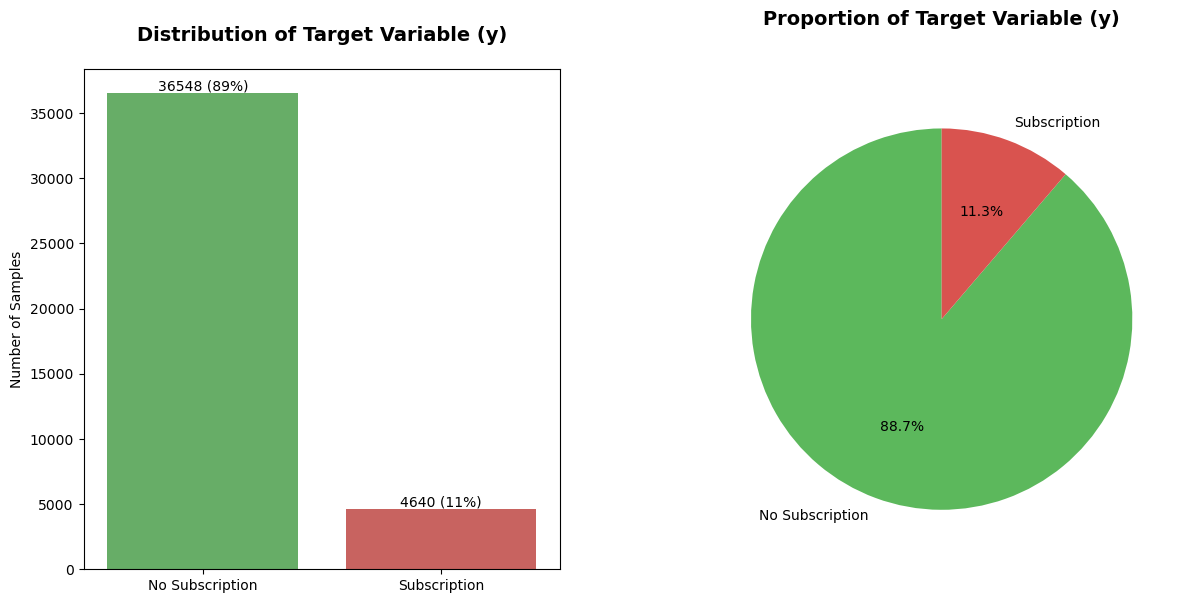

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#5cb85c', '#d9534f'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#5cb85c', '#d9534f'], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**